# Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis

**Name:** Sandeep Reddy Banda  
**Course:** MSCS-634 – Advanced Big Data and Data Mining  
**Lab Assignment:** Lab 1 – Data Visualization, Data Preprocessing, and Statistical Analysis  
**Institution:** University of the Cumberlands

## About My Dataset

For this lab I wanted a dataset that had numbers, categories, and dates, and that was also messy enough to make the preprocessing steps worth doing. I decided to build it around call sessions from an automated phone system (IVR), since that kind of data has a good mix of measurements like call duration, re-prompts, and speech recognition confidence.

I did not want to use any real customer data for a class assignment, so I **generated a simulated dataset** with the script `generate_dataset.py` (included in the repo). The relationships between columns, like more re-prompts leading to longer calls, are assumptions I built in myself. Because of that, the results below should be read as a practice exercise and not as real performance numbers from any system. I also added missing values and a few extreme values on purpose so I would have something to clean.

| Column | What it is |
|---|---|
| call_id | Unique ID for each call session |
| call_date | Date of the call (Jan 1 to Mar 31, 2026) |
| hour_of_day | Hour the call started (6 to 22) |
| platform | Legacy IVR or New Platform |
| intent | What the caller wanted (Make a Payment, Recent Transactions, Balance Inquiry, Rewards Redemption, Cancel a Payment) |
| call_duration_sec | Length of the call in seconds |
| num_turns | Number of back-and-forth dialogue turns |
| num_reprompts | Number of times the system had to ask again |
| asr_confidence | Speech recognition confidence (0 to 1) |
| api_latency_ms | Backend API response time in milliseconds |
| transferred_to_agent | 1 if the call was sent to a live agent, otherwise 0 |
| csat_score | Post-call survey score (1 to 5) |

---
# Step 1: Data Collection

I imported the libraries I need and loaded the raw CSV into a pandas DataFrame. I used `parse_dates` so `call_date` is treated as a real date, which matters later for the line plot.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

# load the dataset into a pandas DataFrame
df_raw = pd.read_csv("data/ivr_call_sessions_raw.csv", parse_dates=["call_date"])
print("Rows, columns:", df_raw.shape)

Rows, columns: (1200, 12)


The output above shows 1,200 rows and 12 columns. Below are the first five rows using `.head()`.

In [2]:
df_raw.head()

,call_id,call_date,hour_of_day,platform,intent,call_duration_sec,num_turns,num_reprompts,asr_confidence,api_latency_ms,transferred_to_agent,csat_score
0,C10000,2026-01-01,6,Legacy IVR,Cancel a Payment,338.0,8,1,0.739,176.0,0,5.0
1,C10001,2026-01-01,7,Legacy IVR,Cancel a Payment,NaN,12,0,0.679,NaN,1,4.0
2,C10002,2026-01-01,7,Legacy IVR,Recent Transactions,256.0,8,2,NaN,267.0,0,3.0
3,C10003,2026-01-01,7,New Platform,Make a Payment,256.0,4,0,0.823,290.0,0,5.0
4,C10004,2026-01-01,8,Legacy IVR,Recent Transactions,211.0,5,1,0.932,370.0,0,4.0


In these first five rows I can already see some `NaN` values (for example `call_duration_sec` in row 1 and `asr_confidence` in row 2), so I know I'll have missing values to deal with in Step 3.

---
# Step 2: Data Visualization

I made all six kinds of plots from the lab examples. I used the raw data here on purpose, because I wanted to see the problems (outliers, skew) before I started cleaning.

### 2.1 Histogram: distribution of call duration

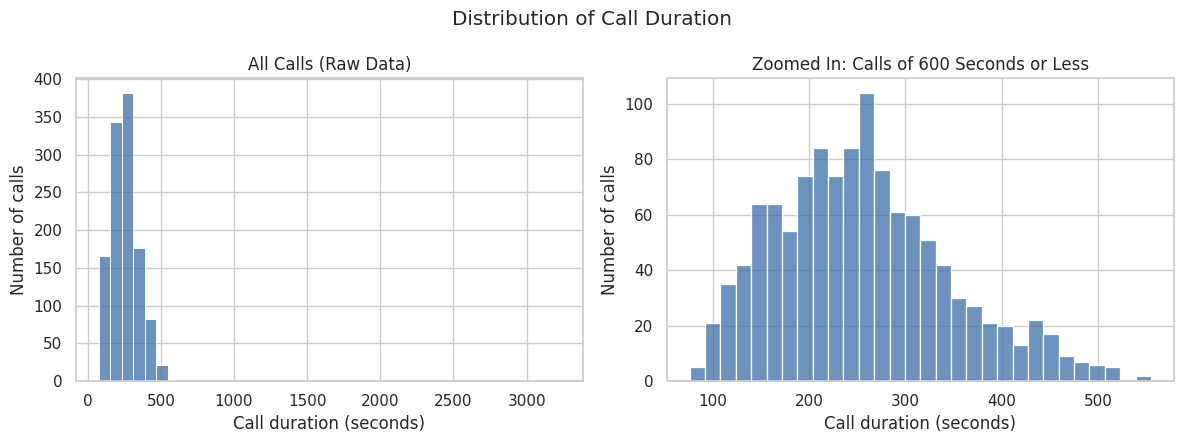

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df_raw["call_duration_sec"].dropna(), bins=40, color="#3b6ea8", ax=axes[0])
axes[0].set_title("All Calls (Raw Data)")
axes[0].set_xlabel("Call duration (seconds)")
axes[0].set_ylabel("Number of calls")

sns.histplot(df_raw.loc[df_raw["call_duration_sec"] <= 600, "call_duration_sec"], bins=30, color="#3b6ea8", ax=axes[1])
axes[1].set_title("Zoomed In: Calls of 600 Seconds or Less")
axes[1].set_xlabel("Call duration (seconds)")
axes[1].set_ylabel("Number of calls")

plt.suptitle("Distribution of Call Duration")
plt.tight_layout()
plt.show()

**What I see:** Most calls last between about 100 and 500 seconds, and the tallest bars are around 200 to 300 seconds. The left plot looks almost empty on the right side, but that is because a small number of sessions run far past 1,500 seconds (14 calls are over 1,000 seconds). Those look like stuck or abandoned sessions and not normal calls. The zoomed-in plot on the right shows the normal calls have a slight right skew.

### 2.2 Box plot: call duration by platform

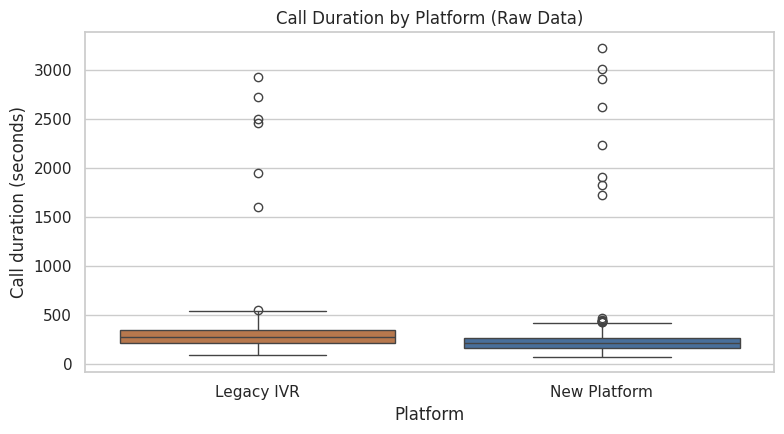

In [4]:
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df_raw, x="platform", y="call_duration_sec", palette=["#c9743b", "#3b6ea8"], hue="platform", legend=False)
plt.title("Call Duration by Platform (Raw Data)")
plt.xlabel("Platform")
plt.ylabel("Call duration (seconds)")
plt.tight_layout()
plt.show()

**What I see:** The median call duration on the Legacy IVR is about 276 seconds, compared to about 221 seconds on the New Platform, so the box for the New Platform sits lower. Both platforms have outlier dots way above the box (over 1,500 seconds), which are the same extreme sessions from the histogram. This plot made me realize I will need to handle outliers before comparing averages, since a single 3,000-second call can move a mean a lot.

### 2.3 Bar chart: median call duration by intent

intent
Balance Inquiry        148.0
Recent Transactions    205.0
Make a Payment         271.0
Cancel a Payment       288.0
Rewards Redemption     319.5
Name: call_duration_sec, dtype: float64


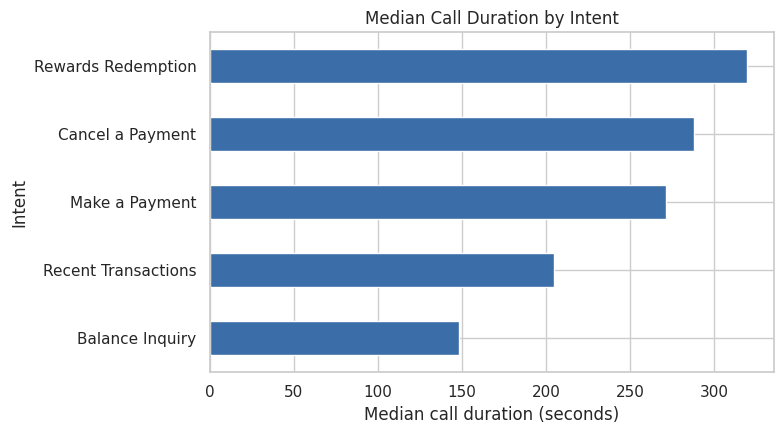

In [5]:
median_by_intent = df_raw.groupby("intent")["call_duration_sec"].median().sort_values()
print(median_by_intent.round(1))

plt.figure(figsize=(8, 4.5))
median_by_intent.plot(kind="barh", color="#3b6ea8")
plt.title("Median Call Duration by Intent")
plt.xlabel("Median call duration (seconds)")
plt.ylabel("Intent")
plt.tight_layout()
plt.show()

**What I see:** Rewards Redemption calls take the longest (median about 320 seconds), followed by Cancel a Payment (288) and Make a Payment (271). Balance Inquiry is the quickest at about 148 seconds. That makes sense to me because a balance check is a simple lookup, while redeeming rewards or cancelling a payment takes more steps. I used the median instead of the mean because the extreme calls would have pulled the averages up.

### 2.4 Scatter plot: dialogue turns vs. call duration

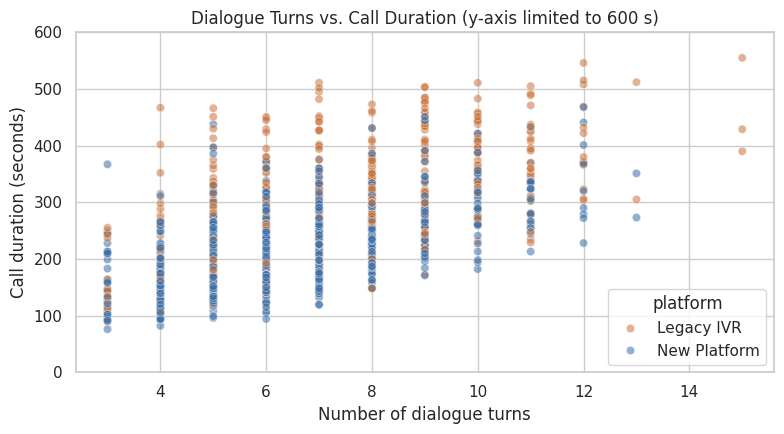

In [6]:
plt.figure(figsize=(8, 4.5))
sns.scatterplot(data=df_raw, x="num_turns", y="call_duration_sec", hue="platform",
                palette=["#c9743b", "#3b6ea8"], alpha=0.55)
plt.ylim(0, 600)   # a few extreme sessions (1,500+ sec) sit above this and are left out of the view
plt.title("Dialogue Turns vs. Call Duration (y-axis limited to 600 s)")
plt.xlabel("Number of dialogue turns")
plt.ylabel("Call duration (seconds)")
plt.tight_layout()
plt.show()

**What I see:** There is a clear upward trend. Calls with more dialogue turns tend to last longer, which is what I expected. The two platforms overlap a lot, but the New Platform points (blue) sit a little lower at the same number of turns. I limited the y-axis to 600 seconds so the main pattern is readable, which means the handful of extreme calls are not shown in this plot.

### 2.5 Line plot: weekly median call duration by platform

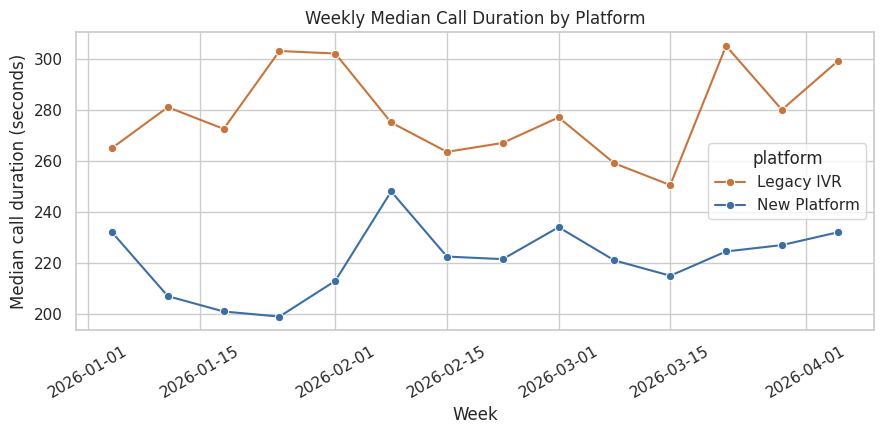

In [7]:
weekly = (df_raw.set_index("call_date")
                .groupby("platform")["call_duration_sec"]
                .resample("W").median()
                .reset_index())

plt.figure(figsize=(9, 4.5))
sns.lineplot(data=weekly, x="call_date", y="call_duration_sec", hue="platform",
             palette=["#c9743b", "#3b6ea8"], marker="o")
plt.title("Weekly Median Call Duration by Platform")
plt.xlabel("Week")
plt.ylabel("Median call duration (seconds)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**What I see:** The New Platform line stays below the Legacy IVR line in every week. The New Platform ranges from about 199 to 248 seconds, and the Legacy IVR ranges from about 250 to 305 seconds. Neither line has a strong trend across the quarter. The early New Platform weeks are probably a little noisy because fewer calls were on it then (the dataset has the share of calls on the New Platform growing over time), so each weekly median is based on fewer calls.

### 2.6 Pie chart: share of calls by intent

intent
Make a Payment         388
Recent Transactions    254
Balance Inquiry        223
Cancel a Payment       165
Rewards Redemption     152
Name: count, dtype: int64


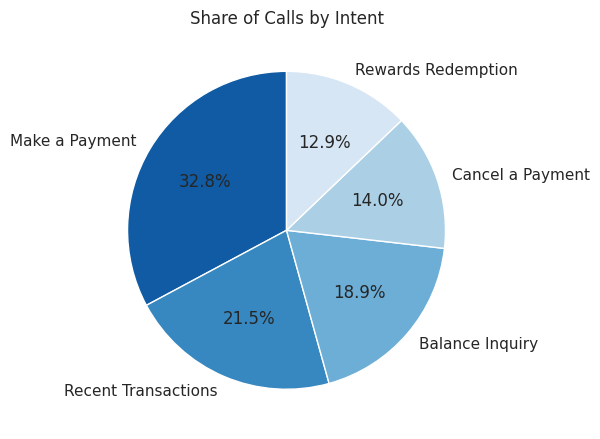

In [8]:
intent_counts = df_raw["intent"].value_counts()
print(intent_counts)

plt.figure(figsize=(6, 6))
plt.pie(intent_counts, labels=intent_counts.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("Blues_r", len(intent_counts)))
plt.title("Share of Calls by Intent")
plt.tight_layout()
plt.show()

**What I see:** Make a Payment is the biggest slice at 32.8%, then Recent Transactions (21.5%), Balance Inquiry (18.9%), Cancel a Payment (14.0%), and Rewards Redemption (12.9%). Payment-related calls (Make a Payment plus Cancel a Payment) together are about 46.8% of everything, so almost half the traffic is about payments. The percentages are based on the rows that have an intent recorded.

---
# Step 3: Data Preprocessing

## 3.1 Handling Missing Values

First I counted how many values were missing in each column and turned it into a percentage.

In [9]:
missing = df_raw.isnull().sum()
missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": (missing / len(df_raw) * 100).round(2)
})
missing_report[missing_report["missing_count"] > 0]

,missing_count,missing_pct
intent,18,1.5
call_duration_sec,12,1.0
asr_confidence,72,6.0
api_latency_ms,60,5.0
csat_score,120,10.0


Five columns have missing values. `csat_score` is the highest at 10% (I'd expect that in real life too since not everybody answers a survey), and the others are between 1% and 6%. Nothing is close to 40%, so I did not need to drop any whole columns. I picked a different technique for each column depending on what the column means:

- **call_duration_sec (drop rows):** This is the main measure I'm studying, so I didn't want to make up values for it. It was only 12 rows (1%), so dropping them costs very little.
- **intent (constant):** I can't guess what a caller wanted, so I filled these with the label "Unknown". That way I keep the rows.
- **asr_confidence (mean):** The values are spread out fairly evenly around the middle, so replacing gaps with the mean seemed reasonable.
- **api_latency_ms (forward fill, then backward fill):** The rows are in time order, so the call right before is a decent guess for the latency. I added a backward fill in case the very first row was missing.
- **csat_score (mode):** The score is a whole number from 1 to 5, and a mean like 3.86 doesn't make sense as a survey answer, so I used the most common value (the mode, which is 4). One downside is that this makes the 4s a little more common than they really are.

In [10]:
df_filled = df_raw.copy()

# 1) columns with more than 40% missing would be dropped (checking whether any qualify)
cols_to_drop = missing_report[missing_report["missing_pct"] > 40].index.tolist()
print("Columns dropped for too many missing values:", cols_to_drop)
df_filled = df_filled.drop(columns=cols_to_drop)

# 2) drop rows where the main measure (call duration) is missing
df_filled = df_filled.dropna(subset=["call_duration_sec"])

# 3) constant fill for the categorical column
df_filled["intent"] = df_filled["intent"].fillna("Unknown")

# 4) mean replacement for ASR confidence
df_filled["asr_confidence"] = df_filled["asr_confidence"].fillna(round(df_raw["asr_confidence"].mean(), 3))

# 5) forward fill for latency (rows are in time order), backward fill for any leading gap
df_filled["api_latency_ms"] = df_filled["api_latency_ms"].ffill().bfill()

# 6) mode replacement for the survey score
df_filled["csat_score"] = df_filled["csat_score"].fillna(df_raw["csat_score"].mode()[0])

print("Rows before:", len(df_raw), "| Rows after:", len(df_filled))
print("Missing values left:", int(df_filled.isnull().sum().sum()))

Columns dropped for too many missing values: []
Rows before: 1200 | Rows after: 1188
Missing values left: 0


Here are some of the same rows before and after filling, so I could check that the techniques did what I meant them to.

In [11]:
check_cols = ["call_id", "intent", "asr_confidence", "api_latency_ms", "csat_score"]
has_gap = df_raw[["intent", "asr_confidence", "api_latency_ms", "csat_score"]].isnull().any(axis=1) & df_raw["call_duration_sec"].notnull()
check_idx = df_raw[has_gap].index[:6]

print("BEFORE handling missing values (NaN = missing):")
display(df_raw.loc[check_idx, check_cols])
print("AFTER handling missing values (same rows):")
display(df_filled.loc[check_idx, check_cols])

BEFORE handling missing values (NaN = missing):


,call_id,intent,asr_confidence,api_latency_ms,csat_score
2,C10002,Recent Transactions,NaN,267.0,3.0
7,C10007,Balance Inquiry,0.867,329.0,NaN
12,C10012,Make a Payment,NaN,311.0,4.0
14,C10014,Rewards Redemption,0.822,NaN,4.0
17,C10017,Rewards Redemption,0.963,237.0,NaN
19,C10019,NaN,0.893,416.0,4.0


AFTER handling missing values (same rows):


,call_id,intent,asr_confidence,api_latency_ms,csat_score
2,C10002,Recent Transactions,0.838,267.0,3.0
7,C10007,Balance Inquiry,0.867,329.0,4.0
12,C10012,Make a Payment,0.838,311.0,4.0
14,C10014,Rewards Redemption,0.822,193.0,4.0
17,C10017,Rewards Redemption,0.963,237.0,4.0
19,C10019,Unknown,0.893,416.0,4.0


For example, row 2 had no `asr_confidence` and now has 0.838 (the mean), row 7 had no `csat_score` and now has 4 (the mode), row 14 had no latency and now has 193 (copied from the row before it), and row 19 has "Unknown" for intent. After all of this the dataset has 1,188 rows and no missing values.

## 3.2 Outlier Detection and Removal

The plots in Step 2 already showed some very long calls. I used the **IQR method** on `call_duration_sec`: any value below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR counts as an outlier.

In [12]:
col = "call_duration_sec"
Q1 = df_filled[col].quantile(0.25)
Q3 = df_filled[col].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.1f}")
print(f"Q3 = {Q3:.1f}")
print(f"IQR = Q3 - Q1 = {IQR:.1f}")
print(f"Lower fence = Q1 - 1.5*IQR = {lower_fence:.1f}")
print(f"Upper fence = Q3 + 1.5*IQR = {upper_fence:.1f}")

outlier_mask = (df_filled[col] < lower_fence) | (df_filled[col] > upper_fence)
outliers = df_filled[outlier_mask]
print(f"\nOutliers found: {len(outliers)} of {len(df_filled)} rows")
outliers[["call_id", "intent", "num_turns", "num_reprompts", col]].sort_values(col, ascending=False).head(10)

Q1 = 190.0
Q3 = 312.2
IQR = Q3 - Q1 = 122.2
Lower fence = Q1 - 1.5*IQR = 6.6
Upper fence = Q3 + 1.5*IQR = 495.6

Outliers found: 25 of 1188 rows


,call_id,intent,num_turns,num_reprompts,call_duration_sec
728,C10728,Balance Inquiry,6,1,3228.0
1173,C11173,Recent Transactions,3,0,3015.0
666,C10666,Make a Payment,7,1,2933.0
1199,C11199,Rewards Redemption,11,3,2910.0
135,C10135,Make a Payment,6,2,2724.0
694,C10694,Make a Payment,5,0,2622.0
290,C10290,Cancel a Payment,6,1,2497.0
998,C10998,Make a Payment,9,2,2456.0
775,C10775,Make a Payment,10,1,2235.0
54,C10054,Rewards Redemption,5,0,1951.0


The IQR came out to 122.2 seconds, which gives an upper fence of 495.6 seconds. That flagged 25 calls. Fourteen of them are the very long sessions (over 1,000 seconds, and up to 3,228). The other 11 are only a little over the fence (roughly 502 to 555 seconds), so those are really just long calls and not obviously errors. I decided to remove all 25 to stay consistent with the method, but I know that means I lost a few legitimate long calls. It is only about 2% of the data.

For latency I tried the **standard deviation (z-score) method** instead. Removing more rows felt like too much, so I capped the extreme values at mean + 3 standard deviations.

In [13]:
df_clean = df_filled[~outlier_mask].copy()

# standard deviation (z-score) check on latency; cap the extreme values instead of dropping rows
lat_mean, lat_std = df_clean["api_latency_ms"].mean(), df_clean["api_latency_ms"].std()
z = (df_clean["api_latency_ms"] - lat_mean) / lat_std
print("Latency values with |z| > 3:", int((z.abs() > 3).sum()))
lat_cap = lat_mean + 3 * lat_std
print(f"Latency max before capping: {df_clean['api_latency_ms'].max():.0f} ms | cap at mean + 3 SD: {lat_cap:.0f} ms")
df_clean["api_latency_ms"] = df_clean["api_latency_ms"].clip(upper=lat_cap).round(0)

print("\nRows before outlier handling:", len(df_filled), "| after:", len(df_clean))
print("Max call duration before:", df_filled[col].max(), "| after:", df_clean[col].max())
df_clean.head()

Latency values with |z| > 3: 13
Latency max before capping: 2810 ms | cap at mean + 3 SD: 779 ms

Rows before outlier handling: 1188 | after: 1163
Max call duration before: 3228.0 | after: 495.0


,call_id,call_date,hour_of_day,platform,intent,call_duration_sec,num_turns,num_reprompts,asr_confidence,api_latency_ms,transferred_to_agent,csat_score
0,C10000,2026-01-01,6,Legacy IVR,Cancel a Payment,338.0,8,1,0.739,176.0,0,5.0
2,C10002,2026-01-01,7,Legacy IVR,Recent Transactions,256.0,8,2,0.838,267.0,0,3.0
3,C10003,2026-01-01,7,New Platform,Make a Payment,256.0,4,0,0.823,290.0,0,5.0
4,C10004,2026-01-01,8,Legacy IVR,Recent Transactions,211.0,5,1,0.932,370.0,0,4.0
5,C10005,2026-01-01,12,Legacy IVR,Recent Transactions,257.0,7,1,0.597,390.0,0,4.0


After this step there are 1,163 rows. The longest call went from 3,228 seconds down to 495 seconds, and the largest latency went from 2,810 ms down to the 779 ms cap (13 latency values were beyond 3 standard deviations).

## 3.3 Data Reduction

I did two kinds of reduction here. For **sampling**, I took a random 50% of the cleaned rows (with `random_state=634` so it's repeatable) and also a fixed sample of 200 rows to show sampling by number. For **dimension elimination**, I looked at whether `hour_of_day` is related to anything before deciding to drop it.

In [14]:
# --- sampling: keep 50% of the rows (by percentage) and also show a fixed-size sample ---
df_reduced = df_clean.sample(frac=0.5, random_state=634)
df_sample_200 = df_clean.sample(n=200, random_state=634)
print("Cleaned data:", df_clean.shape, "| 50% sample:", df_reduced.shape, "| 200-row sample:", df_sample_200.shape)

# --- dimension elimination: check whether hour_of_day tells us anything before dropping it ---
print("\nCorrelation of hour_of_day with the other numeric columns:")
print(df_clean[["hour_of_day", "call_duration_sec", "num_reprompts", "csat_score"]].corr().round(3)["hour_of_day"])

print("\nBEFORE reduction:", df_clean.shape)
display(df_clean.head(3))

df_reduced = df_reduced.drop(columns=["call_id", "hour_of_day"])   # call_id is only an identifier
print("AFTER reduction (50% of rows, 2 columns dropped):", df_reduced.shape)
display(df_reduced.head(3))

Cleaned data: (1163, 12) | 50% sample: (582, 12) | 200-row sample: (200, 12)

Correlation of hour_of_day with the other numeric columns:
hour_of_day          1.000
call_duration_sec    0.010
num_reprompts       -0.000
csat_score           0.035
Name: hour_of_day, dtype: float64

BEFORE reduction: (1163, 12)


,call_id,call_date,hour_of_day,platform,intent,call_duration_sec,num_turns,num_reprompts,asr_confidence,api_latency_ms,transferred_to_agent,csat_score
0,C10000,2026-01-01,6,Legacy IVR,Cancel a Payment,338.0,8,1,0.739,176.0,0,5.0
2,C10002,2026-01-01,7,Legacy IVR,Recent Transactions,256.0,8,2,0.838,267.0,0,3.0
3,C10003,2026-01-01,7,New Platform,Make a Payment,256.0,4,0,0.823,290.0,0,5.0


AFTER reduction (50% of rows, 2 columns dropped): (582, 10)


,call_date,platform,intent,call_duration_sec,num_turns,num_reprompts,asr_confidence,api_latency_ms,transferred_to_agent,csat_score
719,2026-02-21,Legacy IVR,Balance Inquiry,194.0,6,1,0.796,196.0,0,4.0
501,2026-02-07,Legacy IVR,Cancel a Payment,235.0,6,1,0.614,192.0,0,5.0
277,2026-01-20,New Platform,Make a Payment,216.0,7,1,0.953,205.0,0,3.0


`hour_of_day` has almost no correlation with duration (0.010), re-prompts (−0.000), or satisfaction (0.035), so it doesn't seem to add much. `call_id` is only an identifier, so it has no analytical value. I dropped both columns. The data went from 1,163 rows and 12 columns to 582 rows and 10 columns. I kept `call_date` because I already used it for the line plot and it could be useful for time-based work later.

I want to note that I only used the 50% sample for the scaling step below. For the statistics in Step 4 I went back to the full cleaned data, since more rows gives more reliable numbers.

## 3.4 Data Scaling and Discretization

I tried all three scaling methods, each on a different column:

- **Min-Max scaling** on `call_duration_sec` (squeezes values into 0 to 1)
- **Z-score standardization** on `api_latency_ms` (mean 0, standard deviation 1)
- **Decimal scaling** on `num_turns` (divide by 10^j so everything is under 1)

For **discretization** I turned call duration into three groups (Short under 150 seconds, Medium 150 to 300, Long over 300) using `pd.cut`, and split `asr_confidence` into Low / Medium / High with `pd.qcut` so each group has about the same number of rows.

In [15]:
df_scaled = df_reduced.copy()

# Min-Max scaling on call duration (0 to 1)
d = df_scaled["call_duration_sec"]
df_scaled["duration_minmax"] = ((d - d.min()) / (d.max() - d.min())).round(4)

# Z-score standardization on latency
l = df_scaled["api_latency_ms"]
df_scaled["latency_zscore"] = ((l - l.mean()) / l.std()).round(4)

# Decimal scaling on number of turns: divide by 10^j so every value is below 1
j = int(np.ceil(np.log10(df_scaled["num_turns"].abs().max() + 1)))
df_scaled["turns_decimal"] = (df_scaled["num_turns"] / 10**j).round(4)
print(f"Decimal scaling used j = {j}")

# Discretization: turn continuous values into categories
df_scaled["duration_category"] = pd.cut(df_scaled["call_duration_sec"], bins=[0, 150, 300, np.inf],
                                        labels=["Short (<2.5 min)", "Medium (2.5-5 min)", "Long (>5 min)"])
df_scaled["asr_level"] = pd.qcut(df_scaled["asr_confidence"], q=3, labels=["Low", "Medium", "High"])

print("\nBEFORE scaling / discretization:")
display(df_reduced[["call_duration_sec", "api_latency_ms", "num_turns", "asr_confidence"]].head())
print("AFTER scaling / discretization (same rows):")
display(df_scaled[["call_duration_sec", "duration_minmax", "api_latency_ms", "latency_zscore",
                   "num_turns", "turns_decimal", "duration_category", "asr_confidence", "asr_level"]].head())

Decimal scaling used j = 2

BEFORE scaling / discretization:


,call_duration_sec,api_latency_ms,num_turns,asr_confidence
719,194.0,196.0,6,0.796
501,235.0,192.0,6,0.614
277,216.0,205.0,7,0.953
638,263.0,286.0,5,0.836
903,133.0,277.0,6,0.830


AFTER scaling / discretization (same rows):


,call_duration_sec,duration_minmax,api_latency_ms,latency_zscore,num_turns,turns_decimal,duration_category,asr_confidence,asr_level
719,194.0,0.2779,196.0,-0.3378,6,0.06,Medium (2.5-5 min),0.796,Low
501,235.0,0.3797,192.0,-0.3847,6,0.06,Medium (2.5-5 min),0.614,Low
277,216.0,0.3325,205.0,-0.2323,7,0.07,Medium (2.5-5 min),0.953,High
638,263.0,0.4491,286.0,0.7177,5,0.05,Medium (2.5-5 min),0.836,Medium
903,133.0,0.1266,277.0,0.6121,6,0.06,Short (<2.5 min),0.830,Medium


In [16]:
print("Min-Max range:", df_scaled["duration_minmax"].min(), "to", df_scaled["duration_minmax"].max())
print("Z-score mean / std:", round(df_scaled["latency_zscore"].mean(), 4), "/", round(df_scaled["latency_zscore"].std(), 4))
print("Decimal scaling max:", df_scaled["turns_decimal"].max())
print()
print(df_scaled["duration_category"].value_counts())
print()
print(df_scaled["asr_level"].value_counts())

Min-Max range: 0.0 to 1.0
Z-score mean / std: 0.0 / 1.0
Decimal scaling max: 0.12

duration_category
Medium (2.5-5 min)    346
Long (>5 min)         158
Short (<2.5 min)       78
Name: count, dtype: int64

asr_level
Low       195
High      194
Medium    193
Name: count, dtype: int64


The checks confirm it worked: Min-Max gives exactly 0 to 1, the z-scores have a mean of 0 and a standard deviation of 1, and decimal scaling with j = 2 keeps the biggest value at 0.12. In the sample, 346 calls are Medium length, 158 are Long, and 78 are Short. The three ASR levels are almost perfectly balanced (195, 193, 194), which is expected from `qcut`.

---
# Step 4: Statistical Analysis

For this step I used the full cleaned dataset (`df_clean`, 1,163 rows).

## 4.1 General Overview of the Data

In [17]:
# statistics use the full cleaned dataset (not the 50% sample) so the numbers are as reliable as possible
df_clean.info()
print()
df_clean.describe(include="number").round(2)

<class 'pandas.DataFrame'>
Index: 1163 entries, 0 to 1198
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   call_id               1163 non-null   str           
 1   call_date             1163 non-null   datetime64[us]
 2   hour_of_day           1163 non-null   int64         
 3   platform              1163 non-null   str           
 4   intent                1163 non-null   str           
 5   call_duration_sec     1163 non-null   float64       
 6   num_turns             1163 non-null   int64         
 7   num_reprompts         1163 non-null   int64         
 8   asr_confidence        1163 non-null   float64       
 9   api_latency_ms        1163 non-null   float64       
 10  transferred_to_agent  1163 non-null   int64         
 11  csat_score            1163 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(4), str(3)
memory usage: 118.1 KB



,hour_of_day,call_duration_sec,num_turns,num_reprompts,asr_confidence,api_latency_ms,transferred_to_agent,csat_score
count,1163.0,1163.00,1163.00,1163.00,1163.00,1163.00,1163.00,1163.00
mean,14.1,252.95,6.83,0.87,0.84,226.11,0.11,3.89
std,5.0,87.77,2.15,0.98,0.09,88.72,0.31,0.76
min,6.0,76.00,3.00,0.00,0.48,90.00,0.00,1.00
25%,10.0,189.00,5.00,0.00,0.79,173.00,0.00,3.00
50%,14.0,248.00,7.00,1.00,0.85,213.00,0.00,4.00
75%,18.0,307.00,8.00,1.00,0.90,260.00,0.00,4.00
max,22.0,495.00,15.00,6.00,0.99,779.00,1.00,5.00


`.info()` shows 1,163 rows and 12 columns with no null values, which matches my cleaning. Eight columns are numeric. The average call is about 253 seconds with about 6.8 dialogue turns, the average ASR confidence is 0.84, and the average survey score is 3.89 out of 5. About 11% of calls were transferred to an agent (the mean of `transferred_to_agent` is 0.11).

## 4.2 Central Tendency

In [18]:
num = df_clean.select_dtypes(include="number")

central = pd.DataFrame({
    "Min": num.min(),
    "Max": num.max(),
    "Mean": num.mean().round(2),
    "Median": num.median(),
    "Mode": num.mode().iloc[0]
})
central

,Min,Max,Mean,Median,Mode
hour_of_day,6.000,22.00,14.10,14.000,8.000
call_duration_sec,76.000,495.00,252.95,248.000,266.000
num_turns,3.000,15.00,6.83,7.000,7.000
num_reprompts,0.000,6.00,0.87,1.000,0.000
asr_confidence,0.481,0.99,0.84,0.847,0.838
api_latency_ms,90.000,779.00,226.11,213.000,193.000
transferred_to_agent,0.000,1.00,0.11,0.000,0.000
csat_score,1.000,5.00,3.89,4.000,4.000


For `call_duration_sec` the mean (252.95), median (248), and mode (266) are all close together, so after cleaning the distribution is fairly balanced. For `api_latency_ms` the mean (226.11) is higher than the median (213), which tells me there is still a bit of a right skew from the slow calls. `num_reprompts` has a mode of 0, meaning most calls needed no re-prompt at all, but the mean is 0.87 because some calls needed several.

## 4.3 Dispersion

In [19]:
dispersion = pd.DataFrame({
    "Range": num.max() - num.min(),
    "Q1 (25%)": num.quantile(0.25),
    "Q2 (50%)": num.quantile(0.50),
    "Q3 (75%)": num.quantile(0.75),
    "IQR": num.quantile(0.75) - num.quantile(0.25),
    "Variance": num.var().round(2),
    "Std Dev": num.std().round(2)
})
dispersion

,Range,Q1 (25%),Q2 (50%),Q3 (75%),IQR,Variance,Std Dev
hour_of_day,16.000,10.000,14.000,18.000,8.000,25.03,5.00
call_duration_sec,419.000,189.000,248.000,307.000,118.000,7703.46,87.77
num_turns,12.000,5.000,7.000,8.000,3.000,4.63,2.15
num_reprompts,6.000,0.000,1.000,1.000,1.000,0.96,0.98
asr_confidence,0.509,0.789,0.847,0.904,0.115,0.01,0.09
api_latency_ms,689.000,173.000,213.000,260.000,87.000,7871.51,88.72
transferred_to_agent,1.000,0.000,0.000,0.000,0.000,0.10,0.31
csat_score,4.000,3.000,4.000,4.000,1.000,0.58,0.76


Call duration has a range of 419 seconds, an IQR of 118, and a standard deviation of about 88 seconds, so there is a fair amount of spread even after removing outliers. Latency has a similar standard deviation (88.72), but its range (689 ms) is large compared to its IQR (87 ms), which shows that a few slow calls stretch the range even after capping. `asr_confidence` has a tiny variance (0.01), but that's just because it is measured on a 0 to 1 scale.

## 4.4 Correlation Analysis

In [20]:
corr_matrix = num.corr().round(2)
corr_matrix

,hour_of_day,call_duration_sec,num_turns,num_reprompts,asr_confidence,api_latency_ms,transferred_to_agent,csat_score
hour_of_day,1.00,0.01,-0.01,-0.00,-0.02,0.02,-0.00,0.03
call_duration_sec,0.01,1.00,0.56,0.44,-0.20,0.15,0.46,-0.30
num_turns,-0.01,0.56,1.00,0.44,-0.02,0.01,0.09,-0.19
num_reprompts,-0.00,0.44,0.44,1.00,-0.11,0.08,0.15,-0.42
asr_confidence,-0.02,-0.20,-0.02,-0.11,1.00,-0.08,-0.15,0.06
api_latency_ms,0.02,0.15,0.01,0.08,-0.08,1.00,-0.01,-0.04
transferred_to_agent,-0.00,0.46,0.09,0.15,-0.15,-0.01,1.00,-0.40
csat_score,0.03,-0.30,-0.19,-0.42,0.06,-0.04,-0.40,1.00


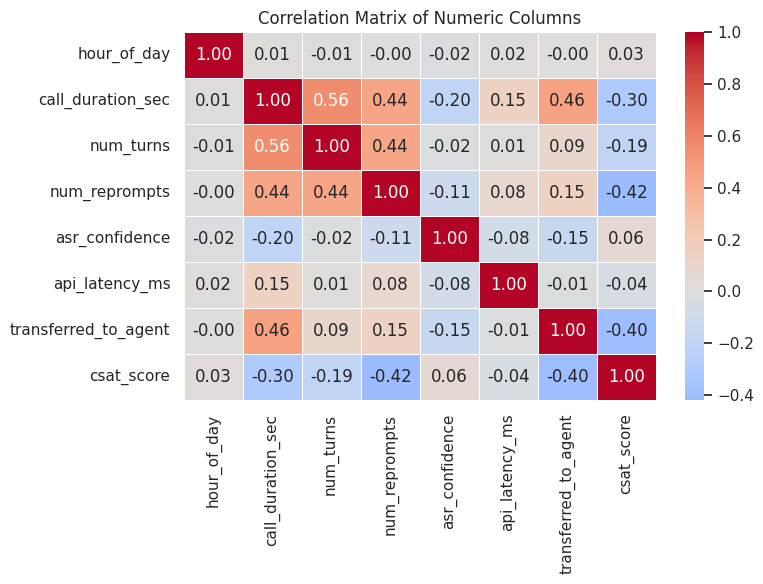

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Columns")
plt.tight_layout()
plt.show()

**What I see:**
- Call duration is most strongly related to the number of dialogue turns (0.56), then to being transferred to an agent (0.46) and to the number of re-prompts (0.44). Duration also has a weak negative relationship with ASR confidence (−0.20), which makes sense since bad recognition means more repeating.
- Survey score goes down as re-prompts (−0.42) and transfers (−0.40) go up. So in this data, customers were less satisfied when the system had to ask again or hand them off.
- `api_latency_ms` only has a weak relationship with duration (0.15).
- `hour_of_day` is near zero with everything, which agrees with my decision to drop it earlier.

I need to remember that correlation doesn't prove one thing causes another. Also, since the data is simulated, these relationships are partly the ones I built in myself, so they show the method working and not a real-world finding.

---
# Saving the Cleaned Data

I saved the cleaned dataset and the final scaled dataset to the `data` folder so they can go in the repo.

In [22]:
df_clean.to_csv("data/ivr_call_sessions_clean.csv", index=False)
df_scaled.to_csv("data/ivr_call_sessions_processed.csv", index=False)
print("Saved cleaned and processed datasets to /data")

Saved cleaned and processed datasets to /data


---
# Reflection

The biggest thing I took from this lab is that the order of the steps matters. Looking at the raw plots first showed me the extreme calls, which told me what to fix in the preprocessing step. Then after cleaning, the statistics were a lot more believable (for example, the mean and median for duration moved close together).

Some decisions were harder than I expected. Choosing between mean, mode, and forward fill for each column made me think about what the column actually means, and the IQR rule removed some perfectly normal long calls along with the truly extreme ones. I chose to keep the method consistent, but in a real project I would probably look at those 11 borderline calls before deleting them.